In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys

sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d
from poisoning.white_box import white_box_poison_function, RGD_update_estimator, PerfGD_update_estimator
from utils.plotting import plot_results_1d, plot_results_2d
import pickle

# Non-linear means

In [2]:
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

## RGD

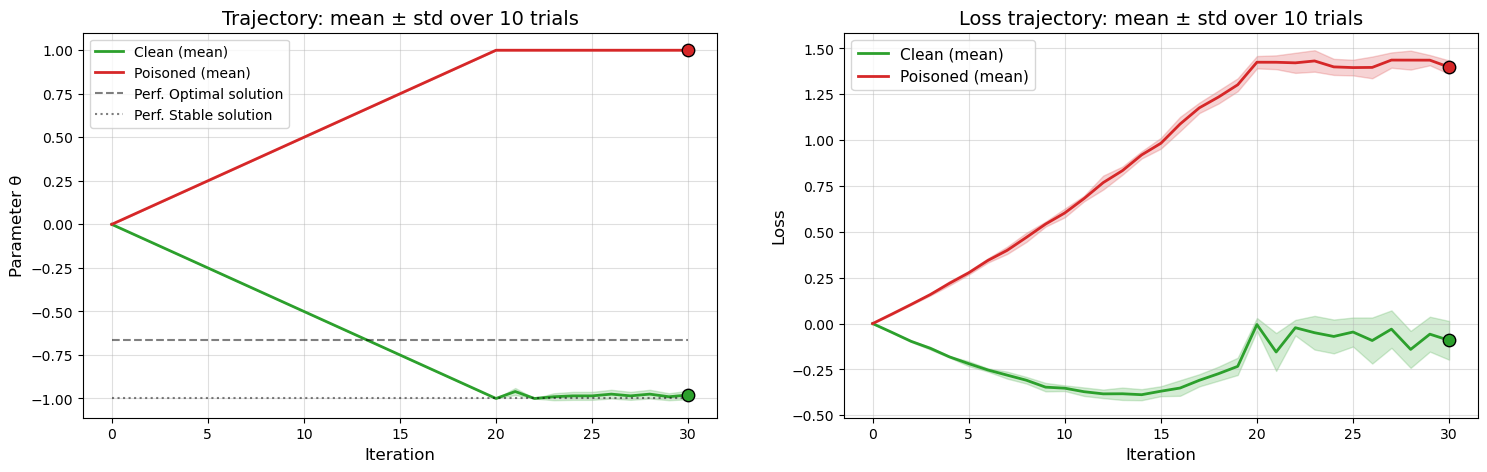

In [5]:
n_trials = 10

n = 500
eta = 0.05
max_iter = 30

poison_steps = 10
poison_step_size = 1
epsilon = 0.5
delta = 10

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=30, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=30, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

## PerfGD

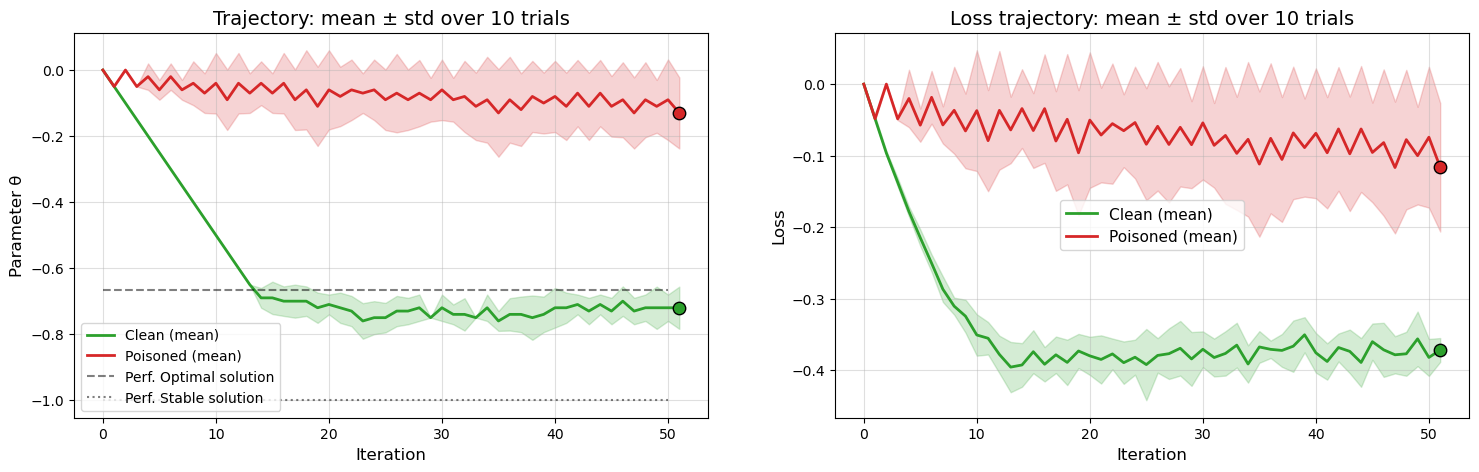

In [3]:
n_trials = 10

n = 500
eta = 0.05
max_iter = 50

poison_steps = 10
poison_step_size = 0.5
epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=50, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=50, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

# Binary Classification

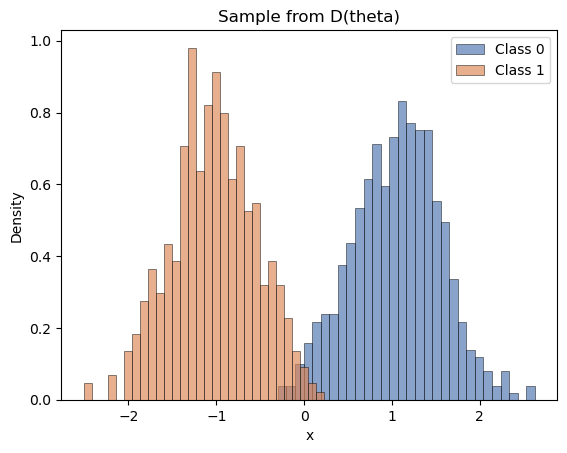

In [2]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)

x, y = D_theta(n=1000, theta=theta_0)

# prettier colors and styled histograms
colors = ['#4C72B0', '#DD8452']  # muted blue and warm orange

x0 = x[(y == 0).bool()].numpy()
x1 = x[(y == 1).bool()].numpy()

plt.hist(x0, bins=30, density=True, alpha=0.65, color=colors[0],
         edgecolor='k', linewidth=0.5, label='Class 0')
plt.hist(x1, bins=30, density=True, alpha=0.65, color=colors[1],
         edgecolor='k', linewidth=0.5, label='Class 1')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sample from D(theta)')
plt.legend(frameon=True)
plt.show()

## RGD

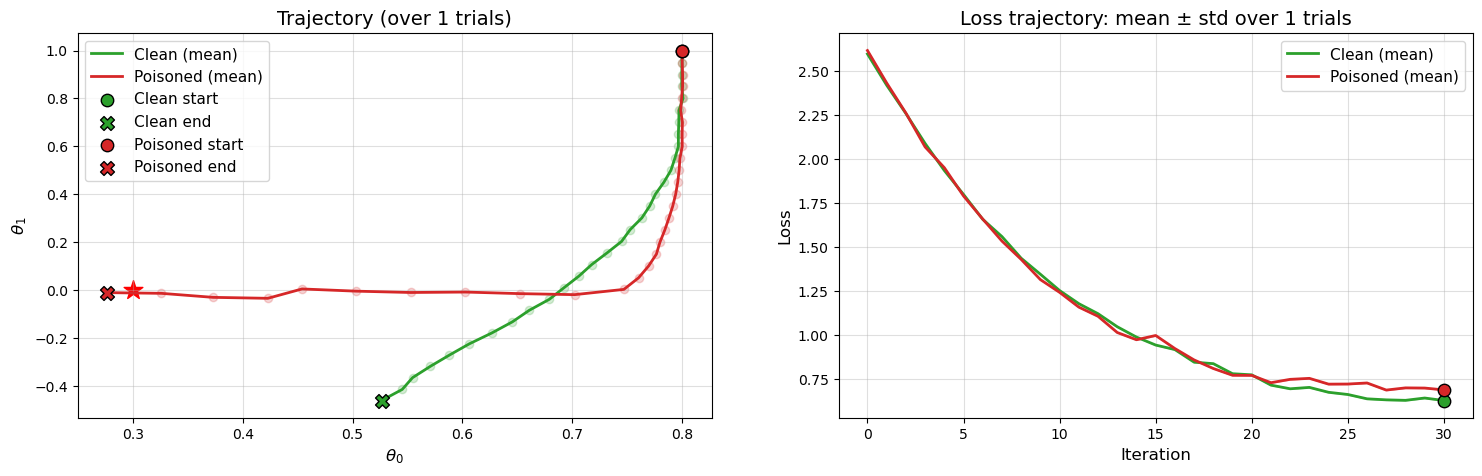

In [22]:
n_trials = 1

n = 500
eta = 0.05
max_iter = 30

poison_steps = 40
poison_step_size = 0.2
epsilon = 0.5
delta = 2

theta_0 = torch.tensor([0.8,1.0])

theta_tgt = torch.tensor([0.3, 0.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                theta_tgt=theta_tgt,
                attack_x_only=True
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )
ax1.scatter(theta_tgt[0].item(), theta_tgt[1].item(), color='red', marker='*', s=200, label='Target Parameter')
plt.show()

## PerfGD

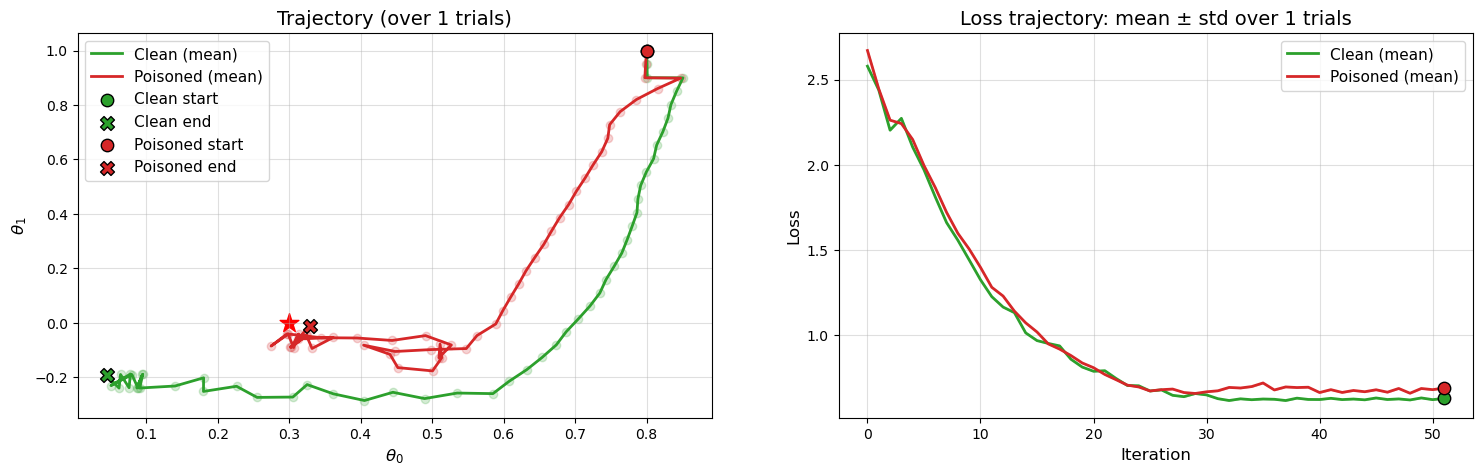

In [21]:
n_trials = 1

n = 500
eta = 0.05
max_iter = 50

poison_steps = 40
poison_step_size = 0.5
epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                attack_x_only=True,
                theta_tgt=theta_tgt
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )
ax1.scatter(theta_tgt[0].item(), theta_tgt[1].item(), color='red', marker='*', s=200, label='Target Parameter')
plt.show()

### Plot full poison for last step only

In [ ]:
delta_vals = np.linspace(0.0, 3, 20)
epsilon = 0.5
poison_step_size = 0.05
poison_steps = 1

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

all_steps_theta, last_step_only = [], []
for delta in delta_vals:
    _theta_all, _, _ , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )
    
    _theta_last, _, _ , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    all_steps_theta.append(_theta_all)
    last_step_only.append(_theta_last)
    
all_steps_theta = np.array(all_steps_theta)
last_step_only = np.array(last_step_only)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta) = plt.subplots(1, 1, figsize=(9, 6), sharex=False)

ax_theta.plot(last_step_only[:,0], last_step_only[:,1], color='red', label='Last only', marker='o', alpha=0.5)
ax_theta.plot(all_steps_theta[:,0], all_steps_theta[:,1], color='blue', label='All steps', marker='x', alpha=0.5)

ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Non Convex Example

In [ ]:
mu, sigma, D_theta, loss, theta_0 = setup_non_convex_1d(perfGD=False)

## RGD

In [ ]:
n_trials = 1

n = 500
eta = 1e-5
max_iter = 100

poison_step_size = 20
epsilon = 1
delta = 10000

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                normalize_grad=False
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(delta//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=False,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.legend()

plt.show()